# Experiment 01 — VQC Reproduction (2 Features, 2 Layers)

**Paper:** Blance & Spannowsky, JHEP 02 (2021) 212  
**Goal:** Reproduce the core VQC from the paper on the HIGGS dataset and compare against the classical MLP baseline.

### Architecture recap
- **State preparation:** Ry(x_i) angle encoding for each feature → qubit
- **Model circuit:** L layers of `Rot(θ,φ,λ)` gates + CNOT entanglement
- **Measurement:** ⟨σz⟩ on qubit 0
- **Postprocessing:** output = ⟨σz⟩ + b (trainable bias)
- **Classification:** sign(output)
- **Optimizer:** Adam (classical) — QNG variant in next cell

### Dataset note
The paper uses a custom Z′→tt̄ simulation. We use the **UCI HIGGS dataset** as a proxy.  
Features selected by correlation analysis: **col 26 (m_bb)** and **col 4 (missing energy magnitude)**  
— the two most discriminating, uncorrelated features for this dataset.

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import numpy as pnp
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score

from utils.data_utils import load_higgs, binary_accuracy

np.random.seed(42)

## 1. Data Loading

In [2]:
N_FEATURES = 2   # paper uses 2 features
N_LAYERS   = 2   # paper uses 2 layers
N_SAMPLES  = 5000

# HIGGS feature columns (0-indexed in CSV):
#   col 26 = m_bb (inv. mass of 2 b-tagged jets) — highest |corr| with label
#   col  4 = missing energy magnitude             — 2nd highest, uncorrelated with col 26
X_train, X_val, X_test, y_train, y_val, y_test = load_higgs(
    path='../data/HIGGS.csv.gz',
    n_samples=N_SAMPLES,
    n_features=N_FEATURES,
    feature_indices=[26, 4],
    scale_range=(0, np.pi),
)

print('X_train:', X_train.shape, '  y label distribution:', np.unique(y_train, return_counts=True))

Selected features (cols [26, 4]): ['m_bb', 'missing energy mag.']
Dataset: 5000 samples | 2 features | train=3000, val=1000, test=1000
X_train: (3000, 2)   y label distribution: (array([-1,  1]), array([1397, 1603]))


## 2. Quantum Circuit

State prep → L model layers → Pauli-Z measurement on qubit 0.

In [3]:
dev = qml.device('default.qubit', wires=N_FEATURES)

@qml.qnode(dev, interface='autograd')
def circuit(weights, x):
    # State preparation: angle encoding
    for i in range(N_FEATURES):
        qml.RY(x[i], wires=i)
    # Model circuit
    for l in range(N_LAYERS):
        for q in range(N_FEATURES):
            qml.Rot(weights[l, q, 0], weights[l, q, 1], weights[l, q, 2], wires=q)
        qml.CNOT(wires=[0, 1])
        qml.CNOT(wires=[1, 0])
    return qml.expval(qml.PauliZ(0))

# Quick sanity check
dummy_w = pnp.array(np.random.uniform(0, 2*np.pi, (N_LAYERS, N_FEATURES, 3)))
dummy_x = pnp.array(X_train[0])
print('Circuit output:', circuit(dummy_w, dummy_x))
print(qml.draw(circuit)(dummy_w, dummy_x))

Circuit output: 0.6360028641657656
0: ──RY(0.15)──Rot(1.15,4.90,3.75)─╭●─╭X──Rot(2.10,0.90,4.09)─╭●─╭X─┤  <Z>
1: ──RY(0.08)──Rot(2.80,0.63,2.89)─╰X─╰●──Rot(0.35,4.54,5.90)─╰X─╰●─┤     


## 3. Model and Loss Function

Full model: `f(w, b, x) = circuit(w, x) + b`  
Loss: MSE — `L = (1/N) Σ (y_i - f(w, b, x_i))²`

In [4]:
def vqc_predict(weights, bias, x):
    """Single sample prediction (raw float output)."""
    return circuit(weights, x) + bias


def vqc_predict_batch(weights, bias, X):
    """Batch prediction — returns array of floats."""
    return pnp.array([vqc_predict(weights, bias, x) for x in X])


def mse_loss(weights, bias, X, y):
    """Mean squared error loss over a batch."""
    preds = vqc_predict_batch(weights, bias, X)
    return pnp.mean((y - preds) ** 2)

## 4. Training (Classical Gradient Descent via Adam)

**Hyperparameters (paper-aligned):**
- 30 epochs
- Batch size 32
- Learning rate 0.01

In [5]:
# --- Hyperparameters ---
N_EPOCHS   = 30
BATCH_SIZE = 32
LR         = 0.01

# --- Initialise parameters ---
np.random.seed(42)
weights = pnp.array(np.random.uniform(0, 2 * np.pi, (N_LAYERS, N_FEATURES, 3)), requires_grad=True)
bias    = pnp.array(0.0, requires_grad=True)

opt = qml.AdamOptimizer(stepsize=LR)

# --- Training loop ---
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

n_train = len(X_train)

for epoch in range(N_EPOCHS):
    # Shuffle training data
    perm = np.random.permutation(n_train)
    X_shuf, y_shuf = X_train[perm], y_train[perm]

    epoch_loss = 0.0
    n_batches  = 0

    for start in range(0, n_train, BATCH_SIZE):
        Xb = X_shuf[start : start + BATCH_SIZE]
        yb = y_shuf[start : start + BATCH_SIZE].astype(float)

        def cost(w, b):
            return mse_loss(w, b, Xb, yb)

        weights, bias = opt.step(cost, weights, bias)
        epoch_loss += cost(weights, bias)
        n_batches  += 1

    # --- Epoch metrics ---
    train_loss = float(mse_loss(weights, bias, X_train, y_train.astype(float)))
    val_loss   = float(mse_loss(weights, bias, X_val,   y_val.astype(float)))

    train_raw  = vqc_predict_batch(weights, bias, X_train)
    val_raw    = vqc_predict_batch(weights, bias, X_val)

    train_acc  = binary_accuracy(y_train, np.array(train_raw))
    val_acc    = binary_accuracy(y_val,   np.array(val_raw))

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch {epoch+1:3d}/{N_EPOCHS} | '
              f'Train loss: {train_loss:.4f}, acc: {train_acc:.3f} | '
              f'Val loss: {val_loss:.4f}, acc: {val_acc:.3f}')

Epoch   1/30 | Train loss: 0.9669, acc: 0.607 | Val loss: 0.9665, acc: 0.617
Epoch   5/30 | Train loss: 0.9572, acc: 0.605 | Val loss: 0.9562, acc: 0.615
Epoch  10/30 | Train loss: 0.9522, acc: 0.602 | Val loss: 0.9529, acc: 0.609
Epoch  15/30 | Train loss: 0.9519, acc: 0.600 | Val loss: 0.9547, acc: 0.596
Epoch  20/30 | Train loss: 0.9499, acc: 0.600 | Val loss: 0.9525, acc: 0.601
Epoch  25/30 | Train loss: 0.9495, acc: 0.604 | Val loss: 0.9519, acc: 0.611
Epoch  30/30 | Train loss: 0.9496, acc: 0.600 | Val loss: 0.9526, acc: 0.601


## 5. Training Curves

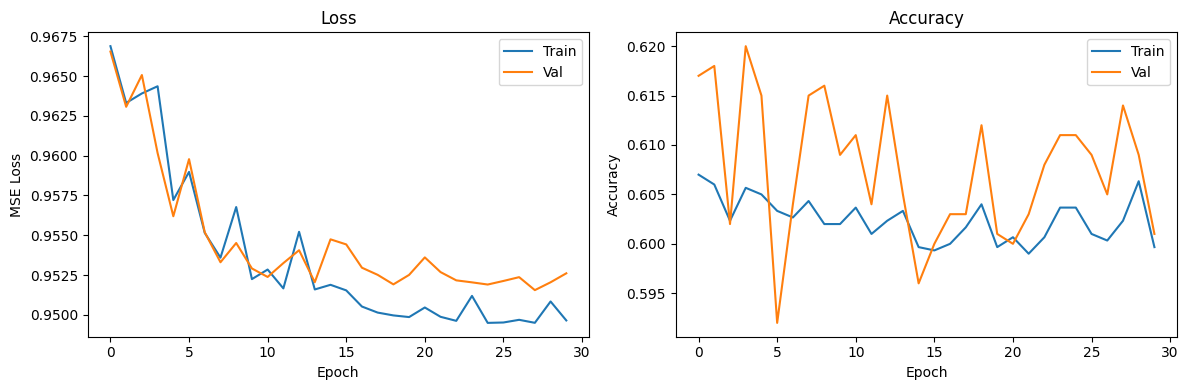

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label='Train')
axes[0].plot(val_losses,   label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(train_accs, label='Train')
axes[1].plot(val_accs,   label='Val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy'); axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/01_training_curves.png', dpi=150)
plt.show()

## 6. Test Evaluation

In [7]:
test_raw = np.array([float(vqc_predict(weights, bias, x)) for x in X_test])
test_acc = binary_accuracy(y_test, test_raw)

# AUC needs 0/1 labels and a score in [0,1]
y_test_01  = (y_test == 1).astype(int)
test_score = (test_raw - test_raw.min()) / (test_raw.max() - test_raw.min() + 1e-8)
test_auc   = roc_auc_score(y_test_01, test_score)

print(f'Test Accuracy: {test_acc:.4f}')
print(f'Test AUC:      {test_auc:.4f}')

Test Accuracy: 0.6160
Test AUC:      0.6087


## 7. ROC Curve

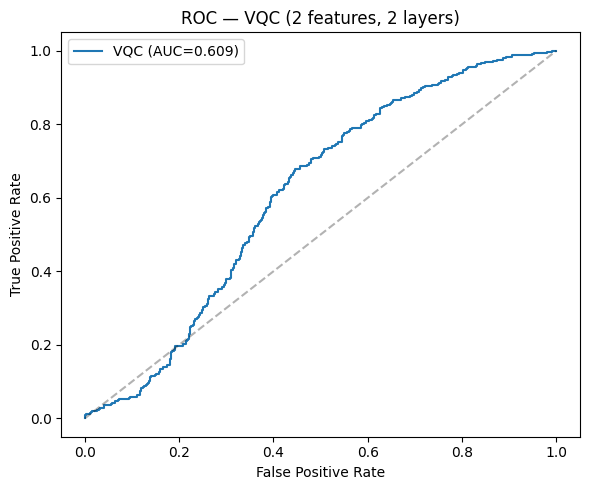

In [8]:
fpr, tpr, _ = roc_curve(y_test_01, test_score)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'VQC (AUC={test_auc:.3f})')
plt.plot([0,1],[0,1], 'k--', alpha=0.3)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC — VQC (2 features, 2 layers)')
plt.legend()
plt.tight_layout()
plt.savefig('../figures/01_roc.png', dpi=150)
plt.show()

## 8. Circuit Visualisation

In [9]:
x_sample = pnp.array(X_test[0])
print('Final trained circuit:')
print(qml.draw(circuit)(weights, x_sample))

print('\nFinal weights (L x Q x 3):')
print(weights)
print('Final bias:', float(bias))

Final trained circuit:
0: ──RY(0.31)──Rot(1.71,6.33,4.84)─╭●─╭X──Rot(0.36,5.44,3.78)──╭●─╭X─┤  <Z>
1: ──RY(0.37)──Rot(3.59,0.45,0.98)─╰X─╰●──Rot(4.72,-0.01,6.09)─╰X─╰●─┤     

Final weights (L x Q x 3):
[[[ 1.71345171  6.33325483  4.84452917]
  [ 3.58941926  0.4546177   0.98014248]]

 [[ 0.3649501   5.44234523  3.77691701]
  [ 4.72435942 -0.00947512  6.09412333]]]
Final bias: -0.7054402400445533


## Summary

| Metric | Classical MLP | VQC (GD) |
|--------|--------------|----------|
| Features | col 26, 4 | col 26, 4 |
| Params | ~19 | `N_LAYERS × N_FEATURES × 3 + 1` = 13 |
| Test Acc | — | *(fill after run)* |
| Test AUC | — | *(fill after run)* |

**Next:** `02_feature_scaling.ipynb` — does adding more features improve VQC performance?